<a href="https://colab.research.google.com/github/LucasBarbosaSilva/MVPSprint3MLAnalytics/blob/main/MVP_Sprint_3_ML_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Lucas Barbosa Leite Silva  
**Matrícula:** 4052025002093    
**Dataset Original:** [Marketing bancário](https://archive.ics.uci.edu/dataset/222/bank+marketing)    
**Dataset Pré-tratado:** [Dataset pré-processado](https://github.com/LucasBarbosaSilva/MVPSprint3MLAnalytics/blob/main/dataset/bank-marketing-pre-processed.csv)    
**Tipo de problema:** Classificação


# 1. Definição do problema

## 1.1 Descrição do problema

Uma instituição bancária portuguesa disponibilizou dados de campanhas de marketing direto (chamadas telefônicas). Através destes dados é possível entender o comportamento da variável alvo (o resultado da campanha), buscando enteder quais os fatores mais influenciam na decisão do cliente se inscrever em um depósito a prazo (variável result_campaign). Este modelo poderá ser utilizado por outras instituições financeiras a fim de entender e predizer o comportamento dos clientes, baseado em variáveis assessórias (como idade, renda anual, número de contatos, etc).

## 1.2 Objetivo do MVP

O objetivo deste projeto é construir e avaliar diferentes modelos de aprendizado de máquina, a fim de encontrar o que melhor se adapta ao problema escolhido. Para isso, diversos modelos devem ser comparados com um modelo baseline, a fim de encontrar o modelo e o conjunto de configurações (como variáveis e hiperparâmetros) que gerem um resultado mais efetivo, apesar de suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** classificação;

**Justificativa:** dado um conjunto de variáveis é preciso determinar se um cliente se encontra na classe A (aceita o deposito) ou se encontra na classe B (recusa o depósito).

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?
2. Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?
3. Ligar mais vezes para um cliente diminui a chance dele contratar?
4. Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

**Critérios de sucesso:**
- **Métrica principal:** as métricas principais deste modelo serão a acurácia e o roc-auc.
- **Resultado mínimo esperado:** superar a acurácia do modelo baseline;
- **Restrição prática:** os modelos não podem demorar mais de 30 segundos para serem treinaos.


# 2. Ambiente, bibliotecas e reprodutibilidade

A seguir, iremos importar todas as bibliotecas que serão utilizadas neste projeto. Além disso, estabelecer algumas configurações globais para o projeto.


In [38]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, KFold, RandomizedSearchCV, train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    recall_score,
    precision_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 22
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 22


## 2.1 Dependências adicionais

Não foram necessárias dependências extras para esse projeto.


## 2.2 Funções auxiliares

A seguir criaremos algumas funções de uso global deste projeto.


In [39]:
def plot_barh_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(2,1, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')

  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=True)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel('Quantidade')
  ax[0].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(no/2, i, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no + yes/2, i, f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(no+yes+100, i, f"Total: {no+yes}", va='center', ha='left', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=True)

  # plot
  df_pivot.plot(kind='barh', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel('Percentual')
  ax[1].set_ylabel(label)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(no/2, i, f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(no + yes/2, i, f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()

In [40]:
def plot_bar_by_hue_result(figsize, df, variable, label, target):
  fig, ax = plt.subplots(1,2, figsize = figsize)
  fig.suptitle(f'Análise da variável {variable}')

  # plot 1
  # Preparação do df
  df_group = df.groupby([variable, target], as_index=False, dropna=False).size()
  df_group['total'] = df_group.groupby(variable, dropna=False)['size'].transform('sum')
  df_pivot = df_group.pivot(index=variable, columns=target, values='size')
  df_pivot['total'] = df_pivot[['yes', 'no']].sum(axis=1)
  df_pivot = df_pivot.sort_values(by="total", ascending=False)
  df_pivot.drop(columns=['total'], inplace=True)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[0], color=['#ff0000','#00ff00'])
  ax[0].set_xlabel(label)
  ax[0].set_ylabel('Quantidade')
  ax[0].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[0].text(i, no/2, f"{no}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, no + yes/2,  f"{yes}", va='center', ha='center', fontsize=9, color='black')
      ax[0].text(i, (no+yes)+350,  f"Total: {no+yes}", va='center', ha='center', fontsize=9, color='blue')

  # plot 2
  # Preparação do df
  df_group['percent'] = df_group.groupby(variable, dropna=False)['size'].transform(lambda x: x / x.sum() * 100)
  df_pivot = df_group.pivot(index=variable, columns=target, values='percent')
  df_pivot = df_pivot.sort_values(by="yes", ascending=False)

  # plot
  df_pivot.plot(kind='bar', stacked=True, ax=ax[1], color=['#ff0000', '#00ff00'])
  ax[1].set_xlabel(label)
  ax[1].set_ylabel('Percentual')
  ax[1].tick_params(axis='x', labelrotation=0)

  # Adicionando rótulos
  for i, (no, yes) in enumerate(zip(df_pivot['no'], df_pivot['yes'])):
      ax[1].text(i, no/2,  f"{no:.1f}%", va='center', ha='center', fontsize=10, color='black')
      ax[1].text(i, no + yes/2,  f"{yes:.1f}%", va='center', ha='center', fontsize=10, color='black')
  plt.tight_layout()
  plt.show()
  return df_group

In [41]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }

    # ROC AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)   é um dataset disponível no UCI Machine Learning Repository. Os dados referem-se a campanhas de marketing direto de uma instituição bancária portuguesa. As campanhas de marketing baseavam-se em chamadas telefónicas. Frequentemente, era necessário mais do que um contacto com o mesmo cliente para apurar se o produto (depósito a prazo bancário) seria contratado ("sim") ou não ("não"). O dataset original é composto por 45211 instâncias e 17 colunas.

No entanto, para este projeto, iremos utilizar uma versão do dataset semitratada que foi desenvolvida no MVP da Sprint 2 - Análise de Dados e Boas Práticas ([link do projeto](https://github.com/LucasBarbosaSilva/MVPSprint2AnalisePreProcessamento)). Nesta versão, uma limpeza inicial dos dados já foi realizada, tratando dados faltantes, outliers, dados duplicados e renomeando as colunas para nomes mais significantes. Além disso, o dataset original possui um alto desbalançeamento entre as duas classes alvo, e o projeto anterior tentou diminuir essa diferença aplicando algumas técnicas de deduplicação. Por fim, além das colunas originais do dataset, algumas colunas contínuas foram discretizadas em faixas, para facilitar a análise e modelagem do problema.

Desse modo, a versão do dataset utilizada ao longo deste MVP, se encontra no repositório do GitHub deste projeto ([link](https://github.com/LucasBarbosaSilva/MVPSprint3MLAnalytics/blob/main/dataset/bank-marketing-pre-processed.csv)). A base contém 30888 e 24 colunas (as originais do dataset e algumas criadas no pré-processamento).

## 3.2 Carga dos dados

A seguir, iremos baixar o dataset do repositório GitHub.


In [42]:
# === Carga dos dados ===
url = "https://raw.githubusercontent.com/LucasBarbosaSilva/MVPSprint3MLAnalytics/refs/heads/main/dataset/bank-marketing-pre-processed.csv"
df = pd.read_csv(url, sep=";", keep_default_na=False)

df.head()


,client_age,client_job,client_marital_status,client_education_level,client_financial_default,client_average_annual_balance,client_housing_loan,client_personal_loan,contact_type,contact_day_of_month,...,number_contacts_previous_campaign,result_previous_campaign,result_campaign,client_age_group,contact_week,client_average_annual_balance_group,contact_duration_group,number_contacts_campaign_group,days_last_contact_group,number_contacts_previous_campaign_group
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,...,0,N/A,no,Meia-idade,week 1,"(1536.25, 13014.0]","(200.0, 338.0]","(0, 1]",never_before,not_contacted
1,44,technician,single,secondary,no,29,yes,no,unknown,5,...,0,N/A,no,Meia-idade,week 1,"(-0.001, 146.0]","(124.0, 200.0]","(0, 1]",never_before,not_contacted
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,0,N/A,no,Adulto,week 1,"(-0.001, 146.0]","(59.999, 124.0]","(0, 1]",never_before,not_contacted
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,...,0,N/A,no,Meia-idade,week 1,"(533.0, 1536.25]","(59.999, 124.0]","(0, 1]",never_before,not_contacted
4,33,unknown,single,unknown,no,1,no,no,unknown,5,...,0,N/A,no,Adulto,week 1,"(-0.001, 146.0]","(124.0, 200.0]","(0, 1]",never_before,not_contacted


## 3.3 Visão geral do dataset

O dataset é composto por 23 features e 1 target. Como já houve um pré-processamento inicial, não há presença de valores nulos ou dados duplicados. As colunas **client_age_group, contact_week,
client_average_annual_balance_group, contact_duration_group, number_contacts_campaign_group, days_last_contact_group, number_contacts_previous_campaign_group** contém valores discretizados das colunas **cliente_age, contact_day_of_month, client_average_annual_balance, contact_duration, number_contacts_campaign, days_last_contact, number_contacts_previous_campaign**. Por isso, neste projeto, iremos utilizar descartar as colunas originais e utilziar apenas as discretizadas.

A coluna result_campaign é a nossa variável target e contém apenas dois valores possíveis: sim e não, indicando se o cliente aceitou ou não o depóstio a prazo.


A seguir, verificamos o formato do dataset e os tipos dos dados:

In [43]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (30888, 24)

Tipos de dados:


,tipo
client_age,int64
client_job,object
client_marital_status,object
client_education_level,object
client_financial_default,object
client_average_annual_balance,int64
client_housing_loan,object
client_personal_loan,object
contact_type,object
contact_day_of_month,int64


Verificando a presença de valores ausentes:

In [44]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
client_age,0
client_job,0
client_marital_status,0
client_education_level,0
client_financial_default,0
client_average_annual_balance,0
client_housing_loan,0
client_personal_loan,0
contact_type,0
contact_day_of_month,0


Verificando a presença de duplicatas:

In [45]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


In [46]:
display(df.sample(5, random_state=SEED))

,client_age,client_job,client_marital_status,client_education_level,client_financial_default,client_average_annual_balance,client_housing_loan,client_personal_loan,contact_type,contact_day_of_month,...,number_contacts_previous_campaign,result_previous_campaign,result_campaign,client_age_group,contact_week,client_average_annual_balance_group,contact_duration_group,number_contacts_campaign_group,days_last_contact_group,number_contacts_previous_campaign_group
25424,24,services,single,secondary,no,258,yes,no,cellular,18,...,0,N/A,no,Jovem,week 3,"(146.0, 533.0]","(200.0, 338.0]","(0, 1]",never_before,not_contacted
11714,25,blue-collar,married,secondary,no,-288,no,yes,cellular,30,...,0,N/A,no,Adulto,week 5,negative,"(200.0, 338.0]","(3.0, 4.0]",never_before,not_contacted
19572,51,technician,married,tertiary,no,1347,yes,yes,cellular,10,...,1,failure,yes,Meia-idade,week 2,"(533.0, 1536.25]","(124.0, 200.0]","(0, 1]","(190.0, 321.5]","(0.999, 2.0]"
8395,40,blue-collar,married,primary,no,137,no,yes,cellular,10,...,0,N/A,no,Meia-idade,week 2,"(-0.001, 146.0]","(200.0, 338.0]","(0, 1]",never_before,not_contacted
11371,47,admin.,single,secondary,no,1305,no,no,cellular,29,...,0,N/A,no,Meia-idade,week 5,"(533.0, 1536.25]","(124.0, 200.0]","(1.999, 3.0]",never_before,not_contacted


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada? | Observações |
|---|---|---|---|---|
| client_age | numérica | Idade dos clientes contactados | não | Será utilizada a coluna com os dados discretizados client_age_group |
| client_job | categórica | Ocupação dos clientes contactados | sim | Valores possíveis: admin., blue-collar, entrepneur housemaid, management, <br> retired, self-employed, services, student, technician, unemployed, unknown |
| client_marital_status | categórica | Situação conjugal dos clientes contactados | sim |  Valores possíveis: maried, single, divorced* unknown |
| client_education_level | categórica | Nível de educação dos clientes contactados | sim | Valores possíveis: primary, secondary, tertiary, unknown |
| client_financial_default | binária | Informa se o cliente já entrou em incumprimento financeiro no passado. | sim | Valores possíveis: yes/no |
| client_average_annual_balance | numérica | Saldo médio anual, em euros | não | Ao invés desta coluna iremos utilizar a coluna client_average_annual_balance_group. |
| client_housing_loan | binária | Informa se o cliente possui empréstimo imobiário. | sim | yes/no |
| client_personal_loan | binária | Informa se o cliente possui empréstimo pessoal | sim | yes/no |
| contact_type | categórica | Tipo de contato durante a campanha | sim | Valores possíveis: cellular, telephone |
| contact_day_of_month | numérica | Dia do último contato | não | Ao invés desta coluna iremos utilizar a coluna contact_week. |
| contact_month | categórica | Mês do último contato. | sim | Valores possíveis: jan, feb, mar, ... oct, nov, dec |
| contact_duration | numérica | Duração do último contato, em segundos | não | Ao invés desta coluna iremos utilizar a coluna contact_duration_group. |
| number_contacts_campaign | numérica | Número de contatos realizados durante esta campanha para este cliente (inclui o último contato). | não | Ao invés desta coluna iremos utilizar a coluna number_contacts_campaign_group. |
| days_last_contact | numérica | Dias de folga: número de dias decorridos desde o último contato com o  cliente em uma <br> campanha anterior.  | não | Ao invés desta coluna iremos utilizar a coluna days_last_contact_group. |
| number_contacts_previous_campaign | numérica | Número de contatos realizados antes desta campanha para  este cliente. | não | Ao invés desta coluna iremos utilizar a coluna days_last_contact_group. |
| result_previous_campaign | categórica | Resultado da campanha de marketing anterior. | sim | Valores possíveis: sucess, failuer, other. |
| client_age_group | categórica | Discretização por faixa etária da coluna client_age.  | sim | Valores possíveis: Jovem, Adulto, Meia-idade, Idoso. |
| contact_week | categórica | Discretização em semanas da variável contact_day_of_month. | sim | Valores possíveis: week 1, week 2, week 3, week 4. |
| client_average_annual_balance_group | categórica | Discretização por frequência da variável client_average_annual_balance | sim | Valores possíveis: negative, (-0.001, 146.0], (146.0, 533.0], (533.0, 1536.25], (1536.25, 13014.0]**|
| contact_duration_group | categórica | Discretização por frequência da variável contact_duration. | sim | Valores possíveis: (59.999, 124.0], (124.0, 200.0], (200.0, 338.0], (338.0, 1419.0]** |
| number_contacts_campaign_group | categórica | Discretização por frequência da variável number_contacts_campaign. | sim | Valores possíveis: (0, 1], (1.999, 3.0], (3.0, 4.0],  (4.0, 16.0]**|
| days_last_contact_group | categórica | Discretização por frequência da variável days_last_contact. | sim | Valores possíveis: never_before, (0.999, 126.0], (126.0, 190.0], (190.0, 321.5], (321.5, 616.0]** |
| number_contacts_previous_campaign_group | categórica | Discretização por frequência da variável number_contacts_previous_campaign. | sim | Valores possíveis: not_contacted, (0.999, 2.0], (2.0, 4.0], (4.0, 20.0]** |
| result_campaign | alvo | Resultado da campanha: indica se o cliente subscreveu um depósito prazo. | sim | yes/no |

\* Nota 1: divorcidado refere-se tanto a pessoas divorciadas, quanto a pessoas viúvas.

** Nota 2: A notação (x, y] indica que o início do intervalo é exclusivo e o final é inclusivo.

Conforme apresentado acima, as variáveis contínuas foram discretizadas para melhorar o desempenho do modelo, facilitar a interpretação e diminuir a chance de overfitting. Com isso, o número total de colunas a serem utilizadas neste problema será 17, 16 features e 1 target. Após a análise do modelo, poderá ser avaliado a redução na quantidade de features a fim de melhorar seu desempenho.

In [47]:
df_columns = df [[
    'client_job',
    'client_marital_status',
    'client_education_level',
    'client_financial_default',
    'client_housing_loan',
    'client_personal_loan',
    'contact_type',
    'contact_month',
    'result_previous_campaign',
    'client_age_group',
    'contact_week',
    'client_average_annual_balance_group',
    'contact_duration_group',
    'number_contacts_campaign_group',
    'days_last_contact_group',
    'number_contacts_previous_campaign_group',
    'result_campaign',
]]

Assim, o formato final do nosso dataset ficou:

In [48]:
print("Formato do dataset:", df_columns.shape)
print("\nTipos de dados:")
display(df_columns.dtypes.to_frame("tipo"))

Formato do dataset: (30888, 17)

Tipos de dados:


,tipo
client_job,object
client_marital_status,object
client_education_level,object
client_financial_default,object
client_housing_loan,object
client_personal_loan,object
contact_type,object
contact_month,object
result_previous_campaign,object
client_age_group,object


Como observado, não temos mais variáveis numéricas na nossa base de dados. Na etapa de preparação, podemos converter as variáveis categóricas e binárias em numéricas através do OrdinalEncoder, OneHotEncoder e da representação de yes/no como dígito 1 ou 0.

# 4. Análise exploratória dos dados

### Análise da variável target

In [49]:
TARGET = "result_campaign"

if TARGET is not None and TARGET in df_columns.columns:
    print("Distribuição do target:")
    display(df_columns[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df_columns[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
result_campaign,
no,26038
yes,4850


,percentual
result_campaign,
no,84.3
yes,15.7


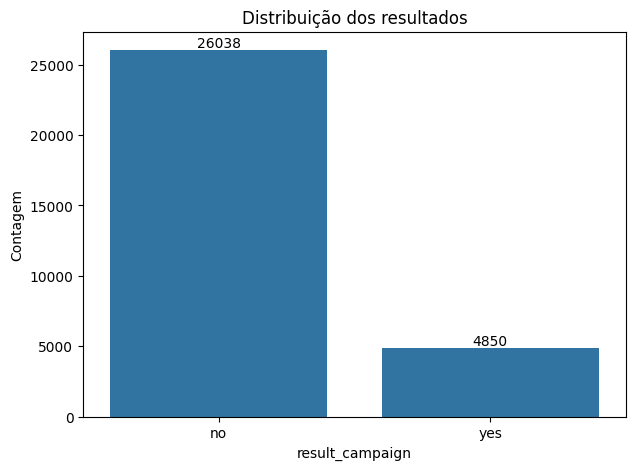

In [50]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
axes = sns.countplot(x=TARGET, data=df_columns)
plt.title('Distribuição dos resultados')
plt.xlabel(TARGET)
plt.ylabel('Contagem')
plt.bar_label(axes.containers[0])
plt.show()

No gráfico a cima, realizamos a análise da variável alvo. Apesar dos esforços do pré-processamento realizado em cima do dataset principal, percebemos ainda um sério desbalanceamento da distribuição da variável alvo result_campaign, com cerca de 85% dos dados registrados como 'no'. Além do mais, percebemos que não há presença de registros com essa variável nula ou com um valor diferente do esperado (yes/no).

Sendo assim, podemos perceber, que dentre o processamento desse dataset necessitamos:
- Utilizar a validação cruzada, para compensar o desbalanceamento do data set;
- Codificar os valores yes/no em símbolos binários 1/0;

### Análise das variáveis features

Agora iremos analisar as demais variáveis do dataset. Como as demais variáveis são categórias, não precisamos verificar a presença de outliers ou aplicar técnicas de normalização/padronização. No entanto, precisamos verificar se os valores estão dentro das categorias esperadas, como está a distribuição das variáveis e qual a relação delas com a variável target.

In [51]:
variaveis = [
    'client_job',
    'client_marital_status',
    'client_education_level',
    'client_financial_default',
    'client_housing_loan',
    'client_personal_loan',
    'contact_type',
    'contact_month',
    'result_previous_campaign',
    'client_age_group',
    'contact_week',
    'client_average_annual_balance_group',
    'contact_duration_group',
    'number_contacts_campaign_group',
    'days_last_contact_group',
    'number_contacts_previous_campaign_group'
]

In [52]:
print("Análise dos valores presentes em cada coluna do datase:")
for i, variavel in enumerate(variaveis):
  print("-"*120)
  print(f"Coluna {variavel}:")
  print(list(df_columns[variavel].unique()))

Análise dos valores presentes em cada coluna do datase:
------------------------------------------------------------------------------------------------------------------------
Coluna client_job:
['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'admin.', 'services', 'retired', 'self-employed', 'unemployed', 'housemaid', 'student']
------------------------------------------------------------------------------------------------------------------------
Coluna client_marital_status:
['married', 'single', 'divorced']
------------------------------------------------------------------------------------------------------------------------
Coluna client_education_level:
['tertiary', 'secondary', 'unknown', 'primary']
------------------------------------------------------------------------------------------------------------------------
Coluna client_financial_default:
['no', 'yes']
--------------------------------------------------------------------------------------------

Com esta análise, percebemos que não há valores diferentes dos valores esperados para cada variável categórica.

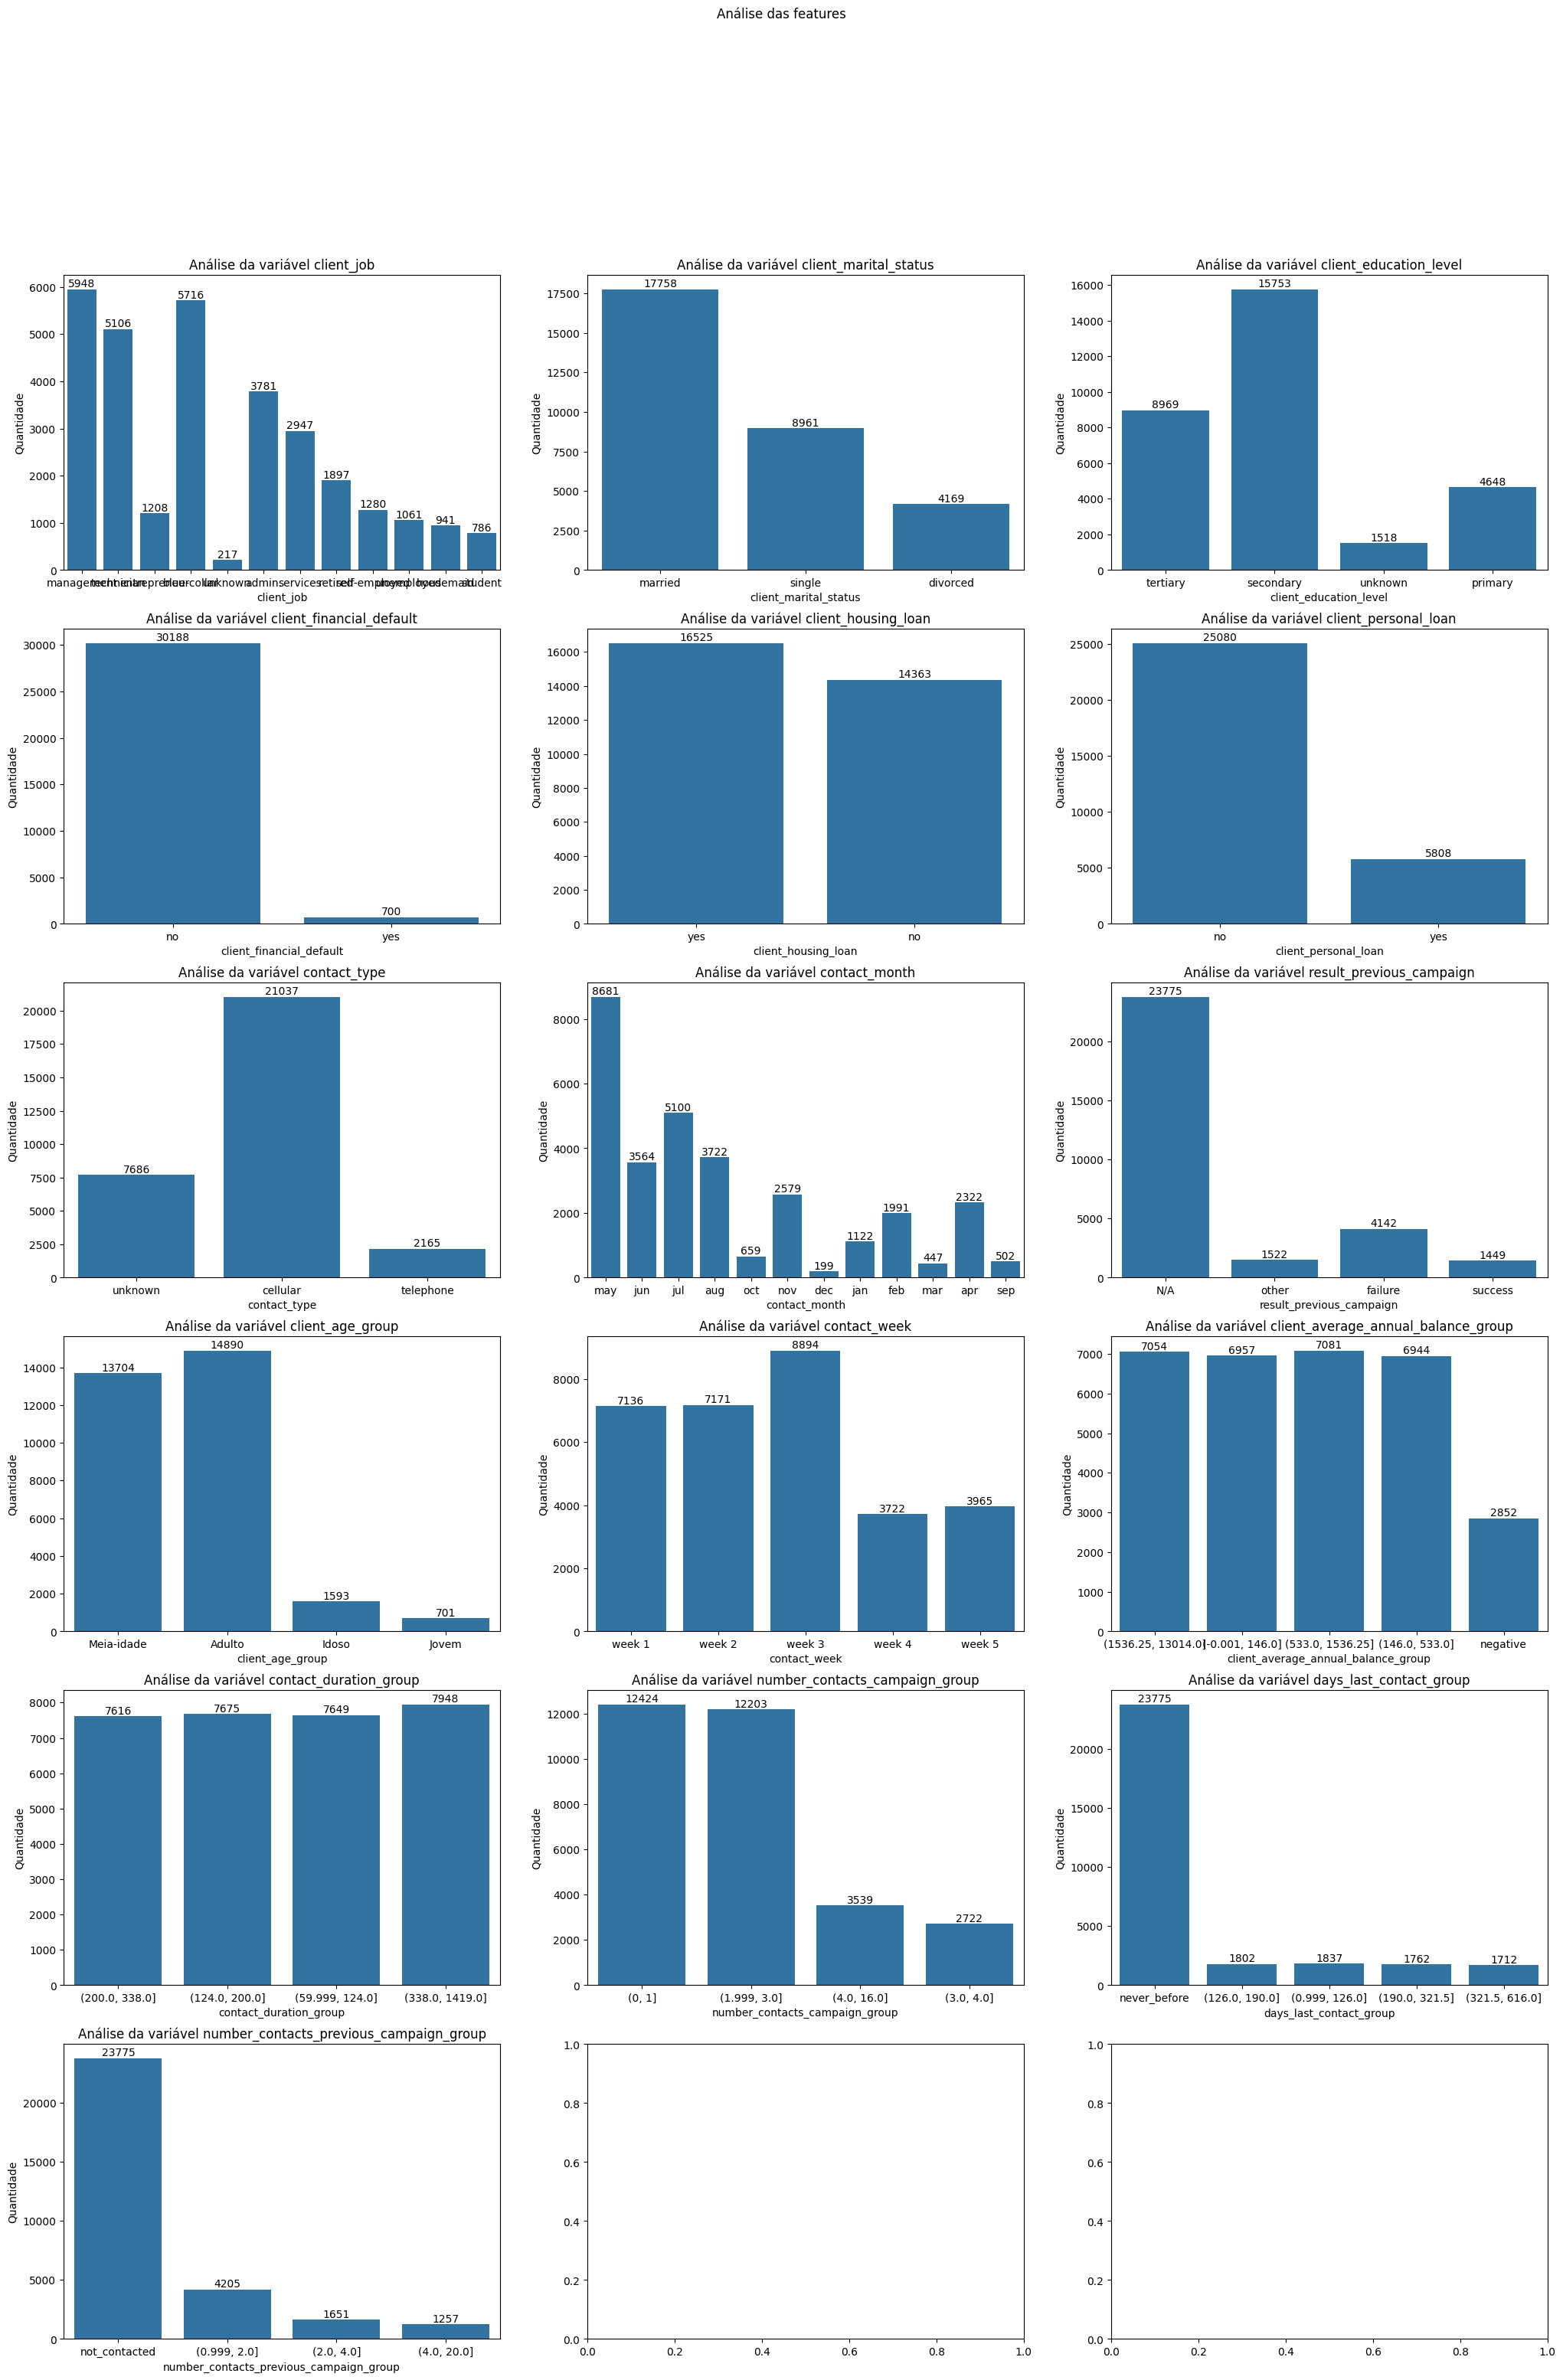

In [53]:
fig, ax = plt.subplots(6,3, figsize = (25, 35))
fig.suptitle('Análise das features')
ax = ax.flatten()
for i, variavel in enumerate(variaveis):
  axes = sns.countplot(x=variavel, data=df_columns, ax=ax[i]  )
  ax[i].set_title(f'Análise da variável {variavel}')
  ax[i].set_xlabel(variavel)
  ax[i].set_ylabel('Quantidade')
  ax[i].bar_label(axes.containers[0])
plt.show()

Com os gráficos a cima, percebemos que algumas variáveis são mais desbalanceadas do que outras, como é o caso das variáveis client_financial_defaul, client_personal_loan, result_previous_campaing, days_last_contact_group. O que reforça mais uma vez a necessidade de validação cruzada, para trazer mais robutez ao modelo.

### Correlação entre as variáveis target e as features

Uma importante análise que precisamos fazer é a relação entre as variáveis features com a variável target. A seguir plotaremos 2 gráficos diferentes para cada variável feature. O gráfico dá esquerda é um gráfico de barras ordenado da maior para menor classe representada na variável, além de mostrar a divisão da sua composição com relação a variável target. Em vermelho temos os clientes que não aceitaram a campanha e em verde os que aceitaram. O segundo gráfico, da direita, mostra os valores percentuais da composição das classes da variável e está ordenado, da esqueda para a direita, do percentual de maior aceitação da campanha para o menor. Em casos em que a visualização dos valores verticais ficou prejudicada, plotamos os gráficos 1 e 2 um em cima do outro e com as barras no formato horizontal.

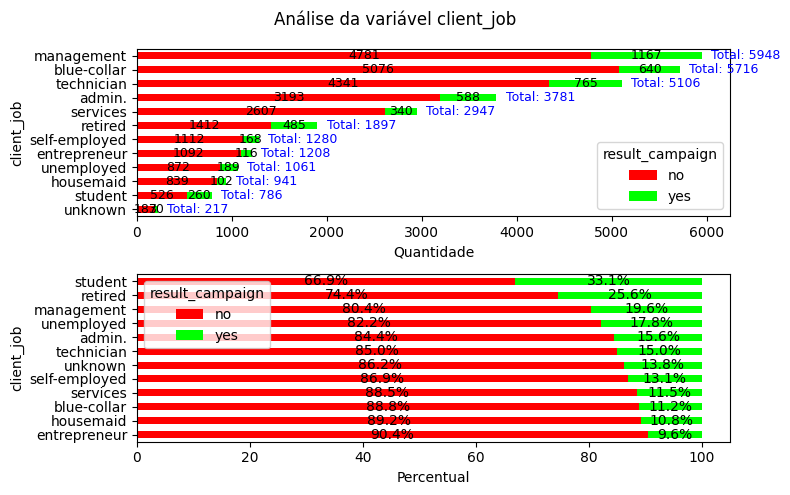

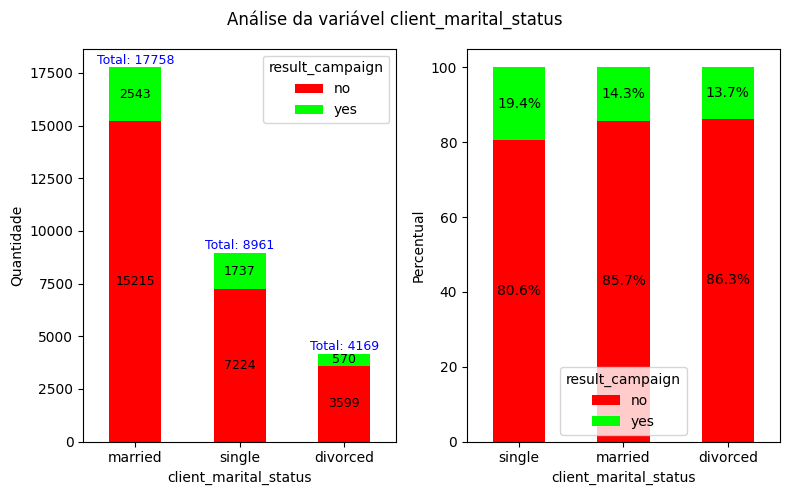

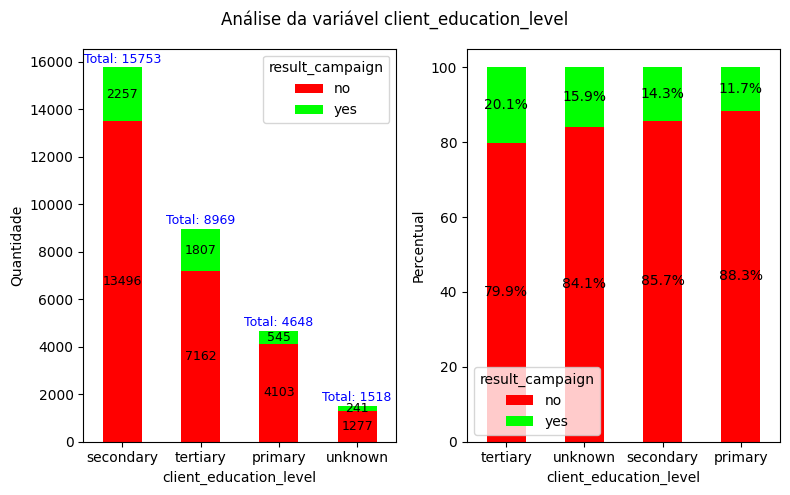

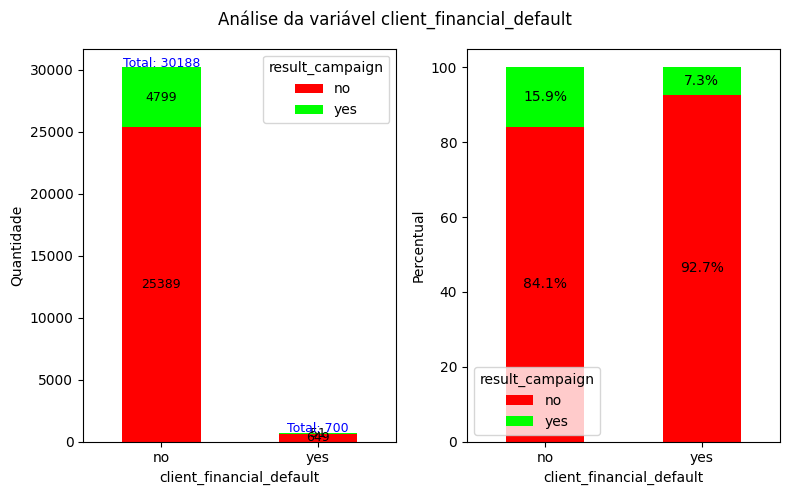

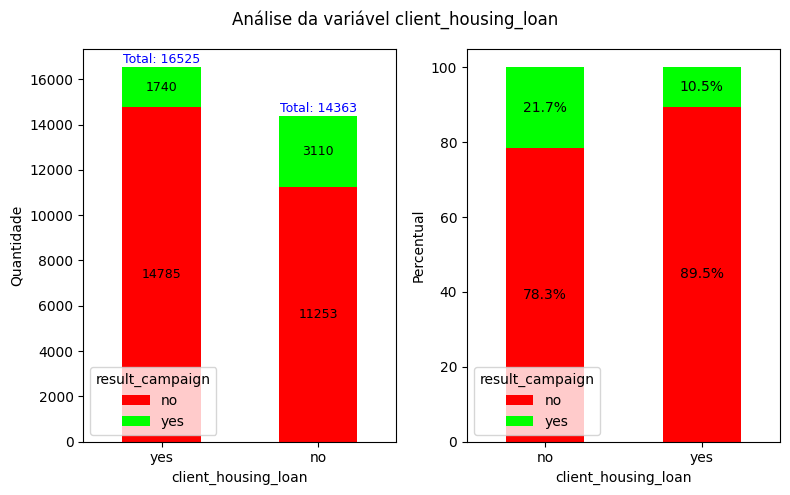

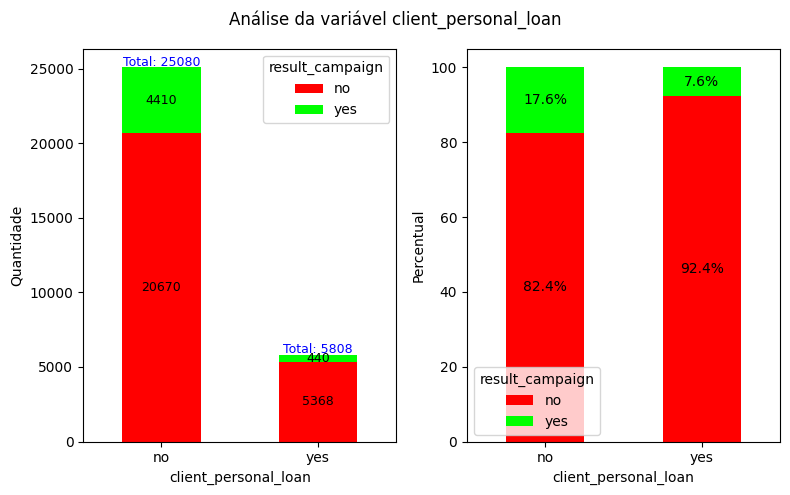

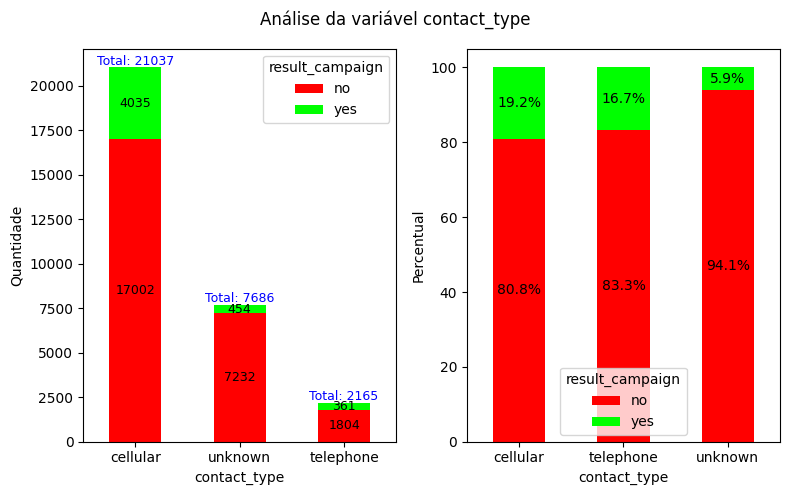

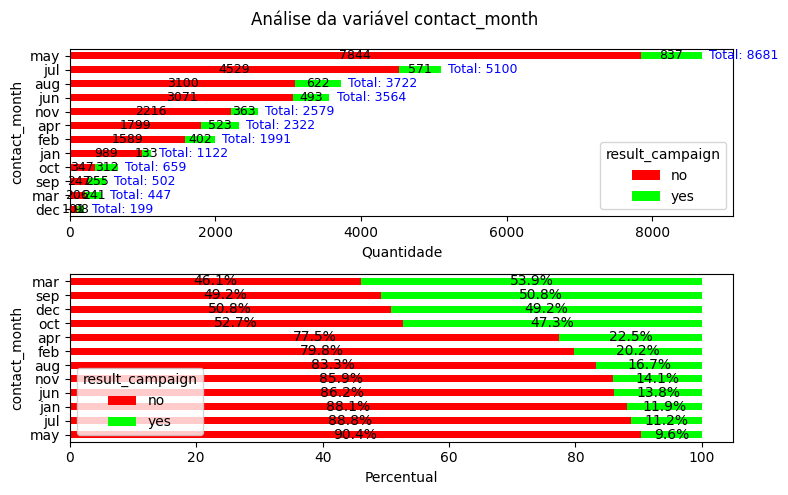

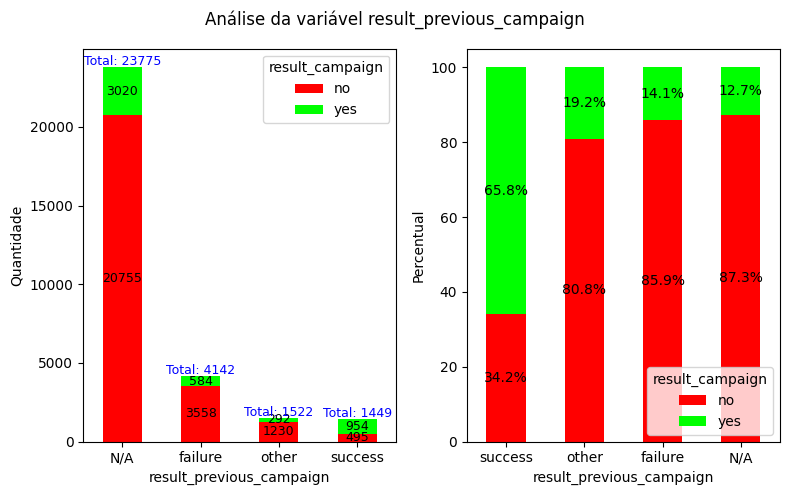

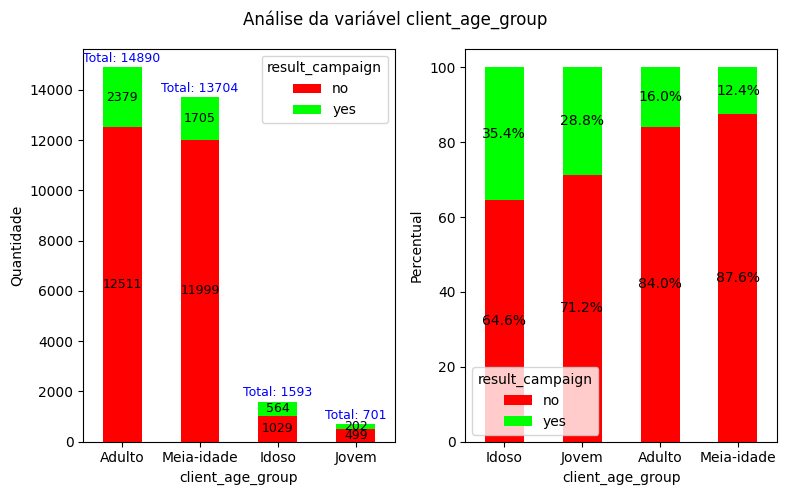

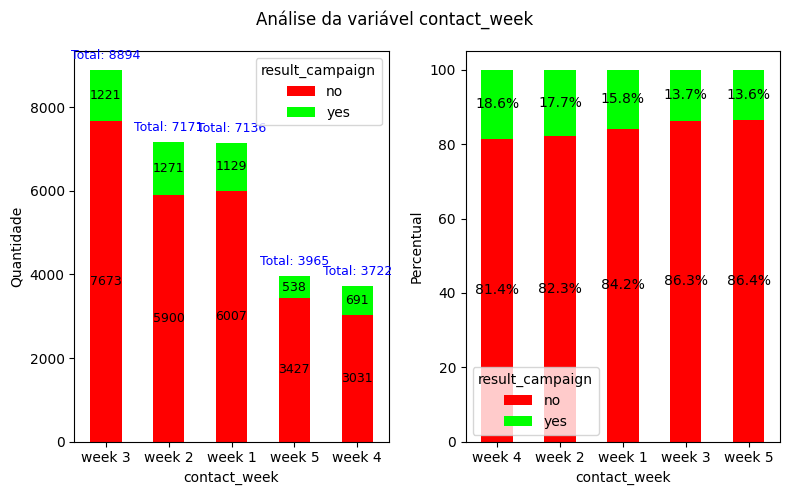

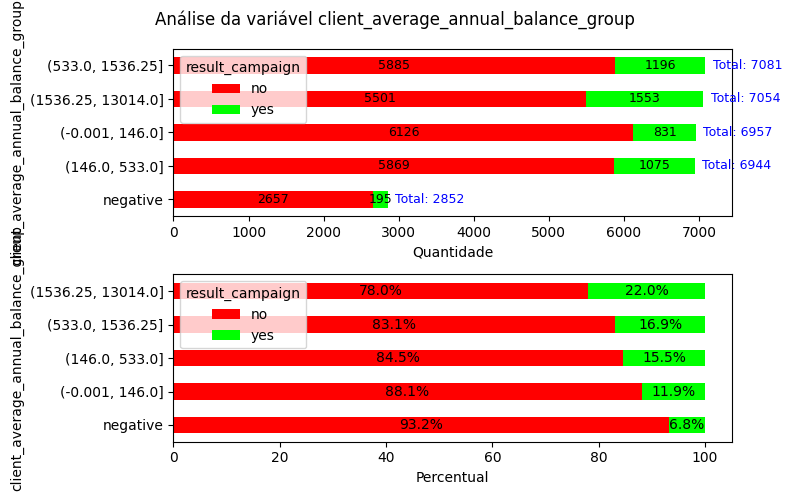

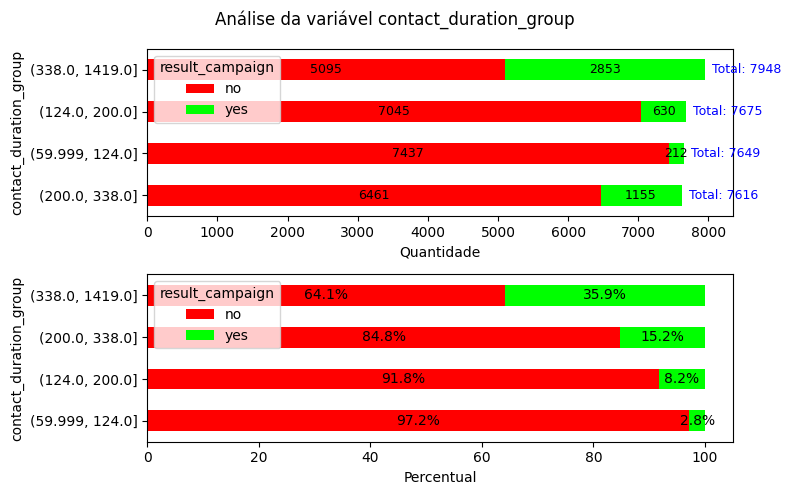

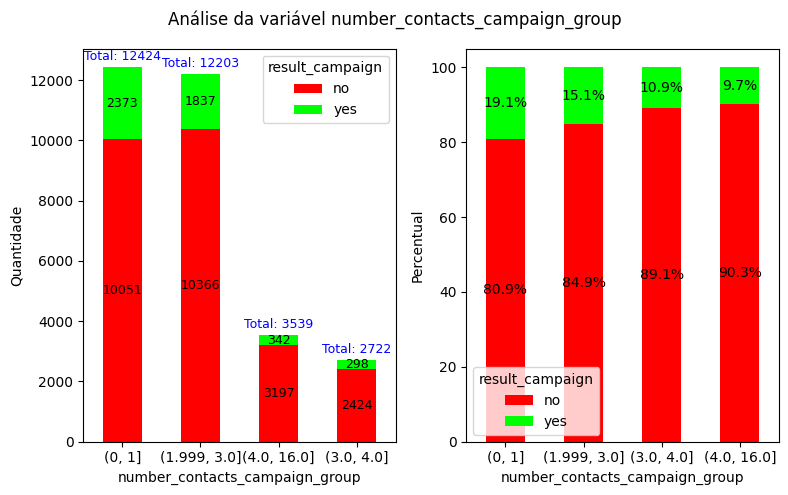

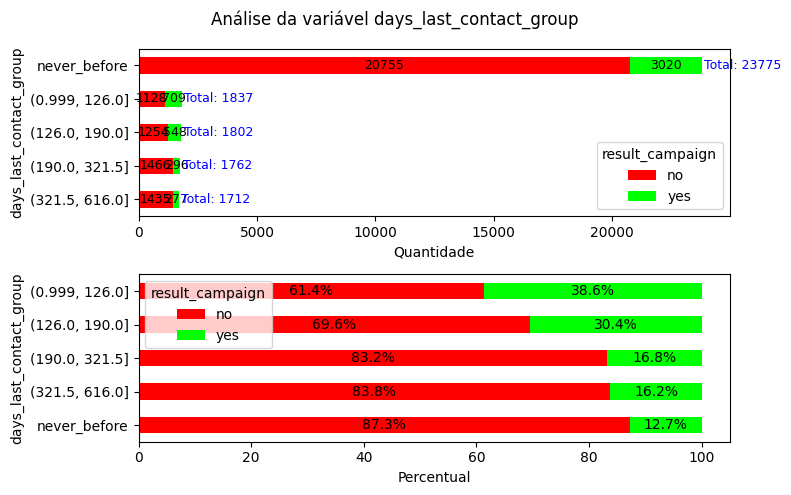

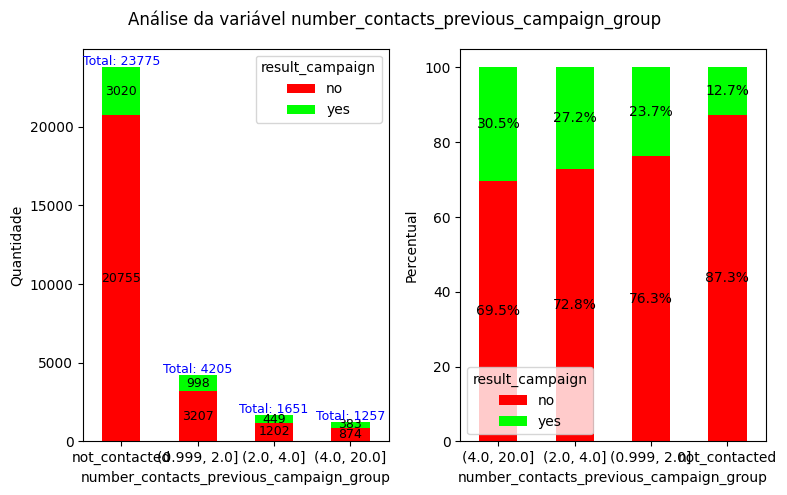

In [54]:
variaveis = [
    ('client_job', True),
    ('client_marital_status', False),
    ('client_education_level', False),
    ('client_financial_default', False),
    ('client_housing_loan', False),
    ('client_personal_loan', False),
    ('contact_type', False),
    ('contact_month', True),
    ('result_previous_campaign', False),
    ('client_age_group', False),
    ('contact_week', False),
    ('client_average_annual_balance_group', True),
    ('contact_duration_group', True),
    ('number_contacts_campaign_group', False),
    ('days_last_contact_group', True),
    ('number_contacts_previous_campaign_group', False)
]
for variavel, horizontal in variaveis:
  if(horizontal):
    plot_barh_by_hue_result((8, 5), df_columns, variavel, variavel, TARGET)
  else:
    plot_bar_by_hue_result((8, 5), df_columns, variavel, variavel, TARGET)

A partir dos gráficos a cima, podemos chegar às seguintes conclusões:

| Variável | Análise quantitativa | Correlação com result_campaign |
| --- | --- | --- |
| client_job | As profissões mais contactadas foram: management, blue-colar e technician.<br>Já as com maior percentual de aceitação foram student, retired e management | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |
| client_marital_status | O status married foi o mais contactado, no entanto o que houve maior taxa de aceitação foi o status single. | A diferença percentual entre as classes não foi tão significativa. |
| client_education_level | O grupo mais entrevistado foi o de nível secondary, mas o de maior taxa de aceitação, foi o nível terciário. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| client_financial_default | A imensa maioria dos clientes não possuíam a situação financial default e este grupo também liderou o percentual de aceitação. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| client_housing_loan | O grupo mais entrevistado foi o dos que possuíam empréstimo imobiliário, <br>mas o grupo que liderou o percentual de aceitação foi o que não tinha. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| client_personal_loan | A grande maioria dos entrevistados não possui empréstimo pessoal e este grupo também liderou o percentual de aceitação. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| contact_type | A grande maioria dos contatos foram realizados por meio de celular e este grupo também liderou o percentual de aceitação. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| contact_month | Os meses de maior contato foram maio, julho e agosto. <br>No entanto, os meses de maior percentual de aceitação foram março, setembro e dezembro. | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |
| result_previous_campaign | A imensa maioria dos clientes contactados não foram contactados em campanhas anteriores. <br>No entanto, a grande maioria dos contactados que obtiveram sucesso na campanha anterior, contrataram novamente o produto. | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |
| client_age_group | A faixa etária mais contactada foi a de adultos, no entanto, a que obteve maior sucesso foi a de idosos. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| contact_week | A semana de maior contato foi a 3ª, mas a de maior aceitação foi a 4ª. | A diferença percentual entre as classes é baixa, <br>pode indicar um impacto baixo no resultado. |
| client_average_annual_balance_group | O grupo mais contactado foi o de balanço anual entre 533 e 1536 euros por ano e o de maior taxa de aceitação foi o de 1536,25 a 13014. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| contact_duration_group | A maioria dos contatos durou entre 338 e 1419 segundos, obtendo também a maior taxa de aceitação. <br>No entanto, essa taxa reduz drasticamente nas demais categorias. | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |
| number_contacts_campaign_group | A maioria dos clientes foram contactados apenas uma vez e este grupo também obteve o maior percentual de aceitação. | A diferença percentual entre as classes é moderada, <br>pode indicar um impacto moderado no resultado. |
| days_last_contact_group | A grande maioria dos clientes não foram contactados em campanhas anteriores. <br>No entanto, o grupo com maior taxa de aceitação foi o que o contato foi feito até 126 dias depois do contato anterior. | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |
| number_contacts_previous_campaign_group | A grande maioria dos clientes não foram contactados na campanha anterior, <br>mas o grupo com maior taxa de aceitação foi o que o número de contatos ficou entre 4 e 20 vezes. | A diferença significativa entre os percentuais de aceitação entre as classes <br>pode indicar que esse atributo pode trazer informações valiosas para a classificação. |


Por fim, podemos realizar a análise da correlação entre as variáveis features e a target através do método de Qui-quadrado e Cramér’s V. O Qui-quadrado testa se existe associação estatística entre as variáveis. Se o p-valor do qui-quadrado for baixo (ex.: < 0.05), significa que há associação significativa entr as variáveis e não podemos simplesmente desprez´-la.

Já o método de Crmér's mede a intensidade dessa associação:
- 0.00 – 0.10 → associação muito fraca;
- 0.10 – 0.20 → associação fraca a moderada;
- 0.20 – 0.30 → associação moderada;
- 0.30 → 0.50 → associação moderada a forte;
- 0.50 em diante, associação forte;

A seguir, vamos calcular esses valores para cada variável, verificando se é possível descartar esta associação estatísticamente e, caso exista, classificando a associação em fraca, fraca-moderada, moderada, moderada-forte e forte.

In [55]:
def obter_avaliacao_p_valor(p_valor):
  if p_valor <= 0.05:
    return "✅ Há associação significativa"
  else:
    return "❌ Não há associação significativa"


In [56]:
def obter_avaliacao_carme(carmer):
  if carmer <= 0.10:
    return "🔴 Fraca"
  elif carmer <= 0.20:
    return "🟠 Fraca-Moderada"
  elif carmer <= 0.30:
    return "🟡 Moderada"
  elif carmer <= 0.50:
    return "🔵 Moderada-forte"
  else:
    return "🟢 Forte"


In [57]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

avaliacao_correlacao = []
for variavel, _ in variaveis:
  # Criar tabela de contingência
  contingency_table = pd.crosstab(df_columns[variavel], df_columns[TARGET])
  # Teste qui-quadrado
  chi2, p, dof, expected = chi2_contingency(contingency_table)
   # Cálculo do Cramér’s V
  n = contingency_table.sum().sum()
  phi2 = chi2 / n
  r, k = contingency_table.shape
  cramers_v = np.sqrt(phi2 / min(k-1, r-1))
  avaliacao_correlacao.append((variavel, p, obter_avaliacao_p_valor(p), cramers_v, obter_avaliacao_carme(cramers_v)))


In [58]:
avaliacao_correlacao.sort(key=lambda x: x[3], reverse=True)
print(f"| {'variavel':<40} | {'p':<25} | {'avaliacao_p_valor':<31} | {'cramers_v':<20} | avaliacao_carme")
print("-"*148)
for variavel, p, avaliacao_p_valor, cramers_v, avaliacao_carme in avaliacao_correlacao:
  print(f"| {variavel:<40} | {p:<25} | {avaliacao_p_valor:<30} | {cramers_v:<20} | {avaliacao_carme}")


| variavel                                 | p                         | avaliacao_p_valor               | cramers_v            | avaliacao_carme
----------------------------------------------------------------------------------------------------------------------------------------------------
| contact_duration_group                   | 0.0                       | ✅ Há associação significativa  | 0.34806587664294136  | 🔵 Moderada-forte
| result_previous_campaign                 | 0.0                       | ✅ Há associação significativa  | 0.308271921340883    | 🔵 Moderada-forte
| contact_month                            | 0.0                       | ✅ Há associação significativa  | 0.2600555504705143   | 🟡 Moderada
| days_last_contact_group                  | 2.2989136347893294e-255   | ✅ Há associação significativa  | 0.19590358695203824  | 🟠 Fraca-Moderada
| contact_type                             | 8.44927599461538e-164     | ✅ Há associação significativa  | 0.15592624438018254  

Como podemos observar na tabela a cima, nenhuma das associações foi classificada como de intensidade forte. No entanto, duas foram classificadas como moderada-forte: contact_duration_group e result_previous_campaign. Já haviamos observado essa correlação na análise do gráfico. No entanto, um ponto de atenção para a variável contact_duration_group: a própria descrição do dataset já traz o alerta de que ela é uma variável que influencia diretamente no resultado. Obviamente, quanto maior o tempo de contato, maior a probabilidade do cliente aceitar a oferta. No entanto, como não temos como prevê qual a duração da chamada antes de contactar o cliente, esta variável não poderá ser utilizada no treinamento do nosso modelo.

 As demais variáveis, foram classificadas entre fraca-moderada e fraca, no entanto, todas elas, foram marcadas como uma associação significativa pela avaliação do p-valor. Ou seja, por menor que seja, pode haver alguma correlação e a análise estatística não nos dá respaudo para descartar essas variáveis. Na etapa de otimização do modelo, poderemos testar diferentes combinações destas colunas, para enteder se podemos reduzir o número de features sem impactar no resultado final.

## 4.1 Síntese da análise exploratória

Assim, ao final desta análise exploratória concluímos que:
- Utilizar a validação cruzada, para compensar o desbalanceamento do data set;
- Codificar os valores yes/no em símbolos binários 1/0;
- Não existem valores ausentes ou valores inválidos para as variaáveis categóricas;
- A variável contact_duration_group não poderá ser utilizada durante o treinamento, pois traz uma informação posterior ao contato;
- As demais features permanecem no dataset até que testes com diferentes combinações de colunas mostrem um conjunto mais efetivo;
- Será necessário codificar as colunas utilizando os codificadores ordinais e não ordinais;

# Respondendo nossas hipóteses


## Hipótese 1

> Clientes com resultado anterior 'sucesso' tendem a se inscrever novamente?

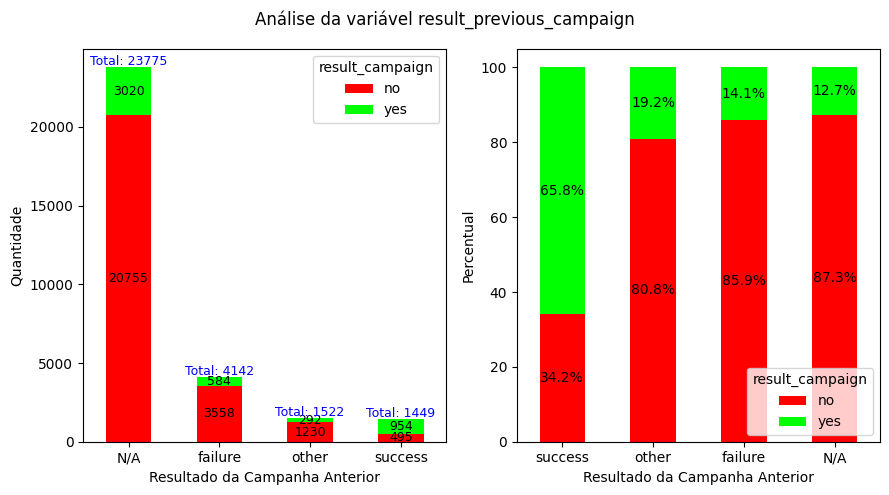

In [60]:
figsize = (9, 5)
variable = 'result_previous_campaign'
label = 'Resultado da Campanha Anterior'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_columns, variable, label, target)

Embora haja uma grande quantidade de clientes que não foram contactados em campanhas anteriores (23775) e que os casos de clientes que foram contactados em campanhas anteriores sejam a menor quantidade de ocorrências (1449), ao observar os percentuais de aceitação da campanha atual, a maioria dos clientes que aceitaram a campanha anterior, também aceitaram a campanha atual.

Então podemos responder que sim, os clientes com sucesso na campanha anterior, foram os mais dispostos a aceitar novamente a campanha. Isso pode indicar que o produto foi muito bem avaliado pelos clientes.

## Hipótese 2

> Clientes mais jovens (15 a 24 anos) tendem a se inscrever mais que clientes adultos (25 a 60 anos)?

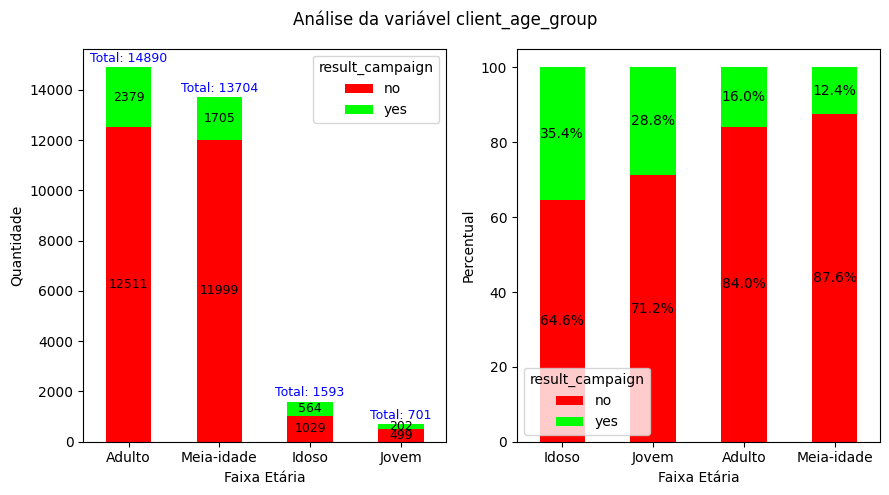

In [61]:
figsize = (9, 5)
variable = 'client_age_group'
label = 'Faixa Etária'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_columns, variable, label, target)

Embora o grupo de jovens foi o menos contactado durante a campanha, a análise percentual revela que foi o grupo com segunda maior taxa de aceitação, estando atrás apenas dos idosos, mas na frente dos considerados adultos (25 a 60 anos).

Então, embora seja necessário uma maior quantidade de contatos com o público jovem, podemos dizer que sim, este público tem uma taxa de aceitação maior do que o de adultos.

## Hipótese 3

> Ligar mais vezes para um cliente diminui a chance dele contratar?

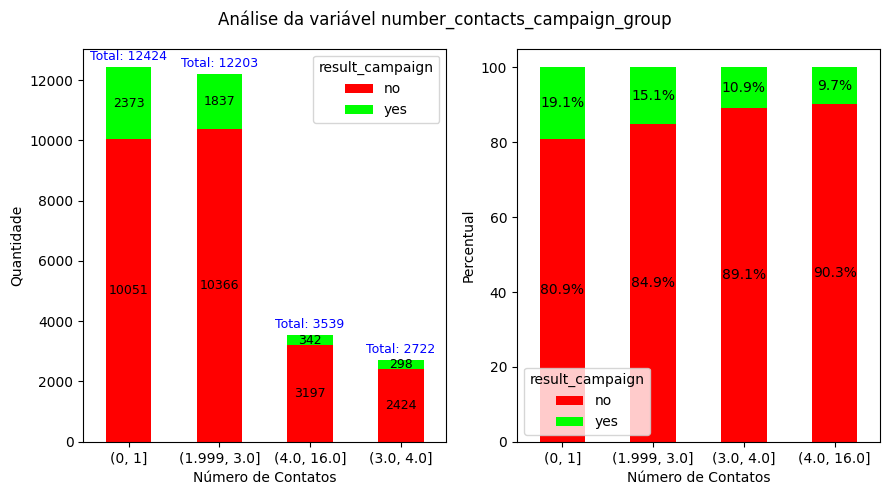

In [62]:
figsize = (9, 5)
variable = 'number_contacts_campaign_group'
label = 'Número de Contatos'
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_columns, variable, label, target)

A grande maioria dos clientes só foram contactados de 1 a 3 vezes. No entanto, observando o gráfico da direita, o percentual com menor taxa de aceitação foi os clientes que receberam de 4 contatos para cima.

Isso revela, que contactar mais de 4 vezes um cliente, dificilmente aumenta as chances dele querer contratar o produto, e que os clientes que estão interessados, geralmente tomam essa decisão entre 1 a 3 contatos.

Então, respondendo a nossa hipótese, podemos dizer sim, diminui, mas melhor seria dizer que não aumenta as chances, pois a maioria dos clientes tomam a decisão nos primeiros contatos.

## Hipótese 4

> Dar mais dias de folga para o cliente, aumenta as chances de fechar contrato?

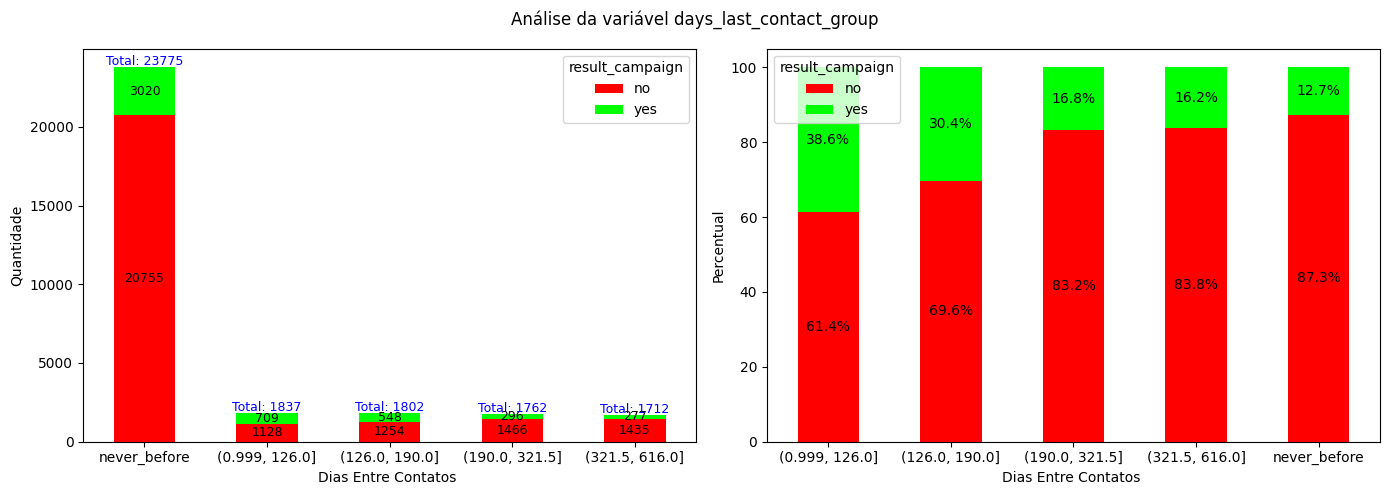

In [63]:
figsize = (14, 5)
variable = 'days_last_contact_group'
label = 'Dias Entre Contatos '
target = 'result_campaign'
df_group = plot_bar_by_hue_result(figsize, df_columns, variable, label, target)

A grande maiorria dos clientes foi contactado pela primeira vez nessa campanha (23775). Dentre os que já tinham sido contactados em campanhas anteriores, a taxa de aceitação está bem maior dentre o período de 1 a 126 dias, seguido pelo período de 127 a 190 dias.

Então podemos dizer, que até 190 dias do contato realizado em campanhas anteriores, os clientes estão mais sucetíveis a repensarem a proposta e aceitar o produto. Após esse período, a taxa de aceitação cai significativamente.

Respondendo a hipótese, depende, até 200 dias é considerado tempo saudável e que geralmente trás bom resultados. Após esse período, diminui significativamente os casos positivos.

# 5. Preparação dos dados e divisão treino/teste

Inicialmente, iremos descartar a variável contact_duration_group:


In [64]:
PROBLEM_TYPE = "classificacao"

columns_to_exclude = ['contact_duration_group']
if TARGET is not None:
    columns_to_exclude.append(TARGET)

features = [c for c in df_columns.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: result_campaign
Número de features: 15
Features: ['client_job', 'client_marital_status', 'client_education_level', 'client_financial_default', 'client_housing_loan', 'client_personal_loan', 'contact_type', 'contact_month', 'result_previous_campaign', 'client_age_group', 'contact_week', 'client_average_annual_balance_group', 'number_contacts_campaign_group', 'days_last_contact_group', 'number_contacts_previous_campaign_group']


## 5.1 Justificativa da divisão

Iremos dividir o nosso dataset em 70% treino e 30% teste. Como o nosso conjunto de dados não é tão pequeno, ele nos permite deixar uma fração maior do conjunto para validar o modelo. Além disso, como se trata de um problema com classes desbalanceados, iremos utilizar o método de validação cruzada (cross-validation) para diminuir a probabilidade de nosso modelo sofrer um overfiting ou underfiting. O método escolhido para a validação cruzada foi o StratifiedKFold a fim de garantir que a proporção entre as classes permaneça em cada Fold.

Com essa divisão, diminuimos a probabilidade do nosso modelo generalizar mal e evitamos o chamado vazamento de dados, pois as informações de teste não são conhecidas na hora do treinamento e vice-versa.


In [65]:
X = df_columns[features].copy()
y = df_columns[TARGET].map({'yes': 1, 'no': 0}).copy() #Convertendo a variável Y em binária 1/0

test_size = 0.30 # tamanho do conjunto de teste

# Separação em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=SEED, stratify=y) # holdout com estratificação

# Criando os folds para a validação cruzada
num_particoes = 10 # número de folds da validação cruzada
cv = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=SEED)

# 6. Pré-processamento e pipeline

A seguir, iremos preparar o pipeline para o processamento dos dados. 3 etapas principais constituem esse pré-processamento:
- Conversão das variáveis binárias em valore numéricos;
- Conversão das variáveis categóricas nominais utilizando o OneHotEncoder;
- Conversão das variáveis categóricas ordinais utilizando o OrdinalEncoder;


In [66]:
cat_bin = [
    'client_financial_default',
    'client_housing_loan',
    'client_personal_loan'
]
cat_nom = [
    'client_job',
    'client_marital_status',
    'contact_type',
    'result_previous_campaign'
]
cat_ord = [
    'contact_month',
    'client_education_level',
    'client_age_group',
    'contact_week',
    'client_average_annual_balance_group',
    'number_contacts_campaign_group',
    'days_last_contact_group',
    'number_contacts_previous_campaign_group'
]

def yes_no_to_binary(X):
    return (X == "yes").astype(int)

categories_ord = [
    ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'],
    ['primary', 'secondary', 'tertiary', 'unknown'],
    ['Jovem', 'Adulto', 'Meia-idade', 'Idoso'],
    ['week 1', 'week 2', 'week 3', 'week 4', 'week 5'],
    ['negative', '(-0.001, 146.0]', '(146.0, 533.0]', '(533.0, 1536.25]', '(1536.25, 13014.0]'],
    ['(0, 1]', '(1.999, 3.0]', '(3.0, 4.0]', '(4.0, 16.0]'],
    ['never_before', '(0.999, 126.0]', '(126.0, 190.0]', '(190.0, 321.5]', '(321.5, 616.0]'],
    ['not_contacted', '(0.999, 2.0]', '(2.0, 4.0]', '(4.0, 20.0]']
]

bin_pipe = Pipeline(steps=[
    ("bin_convert", FunctionTransformer(yes_no_to_binary))
])

categorical_nominal_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_ordinal_pipe = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=categories_ord))
])

preprocess = ColumnTransformer(transformers=[
    ("bin", bin_pipe, cat_bin),
    ("cat", categorical_nominal_pipe, cat_nom),
    ("ord", categorical_ordinal_pipe, cat_ord)
], remainder="drop")

print("Colunas binárias:", cat_bin)
print("Colunas categóricas nominais:", cat_nom)
print("Colunas categóricas ordinais:", cat_ord)


Colunas binárias: ['client_financial_default', 'client_housing_loan', 'client_personal_loan']
Colunas categóricas nominais: ['client_job', 'client_marital_status', 'contact_type', 'result_previous_campaign']
Colunas categóricas ordinais: ['contact_month', 'client_education_level', 'client_age_group', 'contact_week', 'client_average_annual_balance_group', 'number_contacts_campaign_group', 'days_last_contact_group', 'number_contacts_previous_campaign_group']


# 7. Baseline e modelos candidatos

A seguir iremos construir o nosso pipeline de processamento. Como baseline optamos por um classificador simples (DummyClassifier) que utilizará a estratégia da classe mais frequente para prever o resultado. Ou seja, toda vez que lhe for solicitado, o retorno será sempre a classe mais frequente, que no nosso caso seria 0 (o cliente não aceitou a campanha).

Como modelos candidatos vamos dividir em dois blocos: modelos clássicos e modelos ensembles, em suas respectivas categorias (Votting, Bagging e Boosting).

In [67]:
# === Definição de baseline e modelos candidatos ===

baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

# Criando os modelos para o VotingClassifier
bases_votting = []
bases_votting.append(('KNeighborsClassifier',KNeighborsClassifier()))
bases_votting.append(('DecisionTreeClassifier', DecisionTreeClassifier(class_weight="balanced", random_state=SEED)))
bases_votting.append(('GaussianNB', GaussianNB()))

num_trees = 100

candidates = {
    #Clássicos
    "KNeighborsClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", KNeighborsClassifier())
    ]),
    "DecisionTreeClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=SEED))
    ]),
    "GaussianNB": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GaussianNB()),
    ]),
    #Ensembles:
    #Votting:
    "VotingClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", VotingClassifier(bases_votting, voting="soft")),
    ]),
    #Bagging:
    "RandomForestClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=num_trees)),
    ]),
    "ExtraTreesClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", ExtraTreesClassifier(n_estimators=num_trees, random_state=SEED, class_weight='balanced')),
    ]),
    #Bosting:
    "GradientBoostingClassifier": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", GradientBoostingClassifier(n_estimators=num_trees))
        ]),
    "AdaBoostClassifier": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", AdaBoostClassifier(n_estimators=num_trees))
        ]),
    "XGBClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(n_estimators=num_trees))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['KNeighborsClassifier', 'DecisionTreeClassifier', 'GaussianNB', 'VotingClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier', 'GradientBoostingClassifier', 'AdaBoostClassifier', 'XGBClassifier']


## 7.1 Justificativa dos modelos

Os modelos simples de Machine Learning escolhidos foram:
- O KNN (K-Nearest Neighbors);
- Decision Tree (CART);
- Naive Bayes (GaussianNB);

Estes modelos foram escolhidos pela sua facilidade de implementação e de interpretabilidade.

Além disso, esses três modelos foram combinados utilizando a técnica ensemble de Votting, a fim de verificar o resultado dos modelos combinados.

Já dentre os algoritmos ensemble bagging, escolhemos o Random Forest e o Extra Trees. Enquanto que o Random Florest testa diferentes combinações das features a fim de prever um melhor resultado, o Extra Trees ajusta cada árvore de decisão utilizando todo o conjunto de dados de treinamento.

Por fim, avaliamos também os principais algoritmos de ensemble Boosting: AdaBoost e duas implementações do Gradient Boosting, uma provida pelo sklearning (GradientBoostingClassifier), e outra mais otimizada provida pela biblioteca XGBoost.

Estes são os principais algoritmos de ensemble e serão utilizados para avaliar qual a melhor abordagem para este problema. Os algoritmos foram estruturados em suas versões mais simples, com poucas alterações nos parâmetros. Os algortimos baseados em árvores foram testados com a mesma quantidade de árvores.


# 8. Treinamento e avaliação inicial


In [75]:
results = {}
trained_models = {}

t0 = time.time()
scores_bs = cross_validate(
      baseline, X_train, y_train, cv=cv,
      scoring=["accuracy", "precision", "recall", "f1_weighted", "roc_auc"]
  )
train_time = time.time() - t0

metric_test = {metric: scores_bs[metric].mean() for metric in scores_bs if metric.startswith("test") }
results['baseline'] = metric_test
results['baseline']["train_time_s"] = round(train_time, 3)
trained_models['baseline'] = baseline

for name, model in candidates.items():
  t0 = time.time()
  scores_dt = cross_validate(
      model, X_train, y_train, cv=cv,
      scoring=["accuracy", "precision", "recall", "f1_weighted", "roc_auc"]
  )
  train_time = time.time() - t0

  metric_test = {metric: scores_dt[metric].mean() for metric in scores_dt if metric.startswith("test") }
  results[name] = metric_test
  results[name]["train_time_s"] = round(train_time, 3)
  trained_models[name] = model

show_results_table(results)


,test_accuracy,test_precision,test_recall,test_f1_weighted,test_roc_auc,train_time_s
baseline,0.842977,0.000000,0.000000,0.771154,0.500000,1.256
KNeighborsClassifier,0.845150,0.515546,0.248907,0.821761,0.699211,8.763
DecisionTreeClassifier,0.769622,0.292447,0.329894,0.775062,0.592384,2.329
GaussianNB,0.770640,0.330987,0.451540,0.784242,0.718822,1.350
VotingClassifier,0.831969,0.453246,0.333134,0.821220,0.726344,10.041
RandomForestClassifier,0.838490,0.472716,0.236234,0.815247,0.728065,24.933
ExtraTreesClassifier,0.825401,0.407183,0.245651,0.806903,0.670472,32.154
GradientBoostingClassifier,0.860228,0.662293,0.225913,0.829969,0.790559,27.467
AdaBoostClassifier,0.857823,0.669517,0.186746,0.822170,0.766896,17.762
XGBClassifier,0.855280,0.577453,0.294262,0.834956,0.779687,4.223


## 8.1 Análise dos resultados iniciais
Os cinco modelos com melhor **acurácia** foram:
1. GradientBoostingClassifier (0.860228)
2. AdaBoostClassifier (0.857823)
3. XGBClassifier (0.855280)
4. KNeighborsClassifier (0.845150)
5. baseline (0.842977)

Se olharmos apenas para a métrica da acuáricia, poderíamos pensar que o modelo baseline está quase melhor do que os outros modelos mais elaborados. No entanto, isso acontece porque o modelo DummyClassifier utiliza a estratégia do mais frequente. Ou seja, a categoria mais frequente será a escolhida na hora de realizar a predição. Como vimos na etapa da análise exploratória, 84% dos nossos dados, são da categoria "no", e foi esta a categoria que o DummyClassifier escolheu.

Mas, se olharmos para as demais métricas, percebemos que o modelo zerou na precisão, recall e no f1-score. Isso quer dizer que ele não conseguiu predizer corretamente nenhum dos verdadeiros positivos (classe "true"). Já a métrica ROC-AUC fica em 0.5, porque o modelo não tem poder discriminativo: é equivalente a jogar uma moeda.

Isso demonstra como é importante não olhar apenas para a métrica de acurácia, pois muitas vezes ela pode nos induzir a erros. Em cenários de classificação como o de abordar ou não um cliente em uma campanha de marketing, é de fundamental importância identificar bem quais os clientes que aceitariam a campanha. Por isso, a métrica recall pode ser mais desejável do que uma precisão mais alta, já que queremos identificar o máximo possível de clientes que aceitariam a campanha, mesmo que isso traga alguns falsos positivos. Sendo assim, os cinco modelos com a maior taxa de **recall** foram:

1. GaussianNB (0.451540)
2. VotingClassifier (0.333134)
3. DecisionTreeClassifier (0.329894)
4. XGBClassifier (0.294262)
5. KNeighborsClassifier (0.248907)

Além do recall, outra métrica interessante é a área sobre a curva ROC (roc_auc). A curva ROC plota taxa de verdadeiros positivos (TPR = recall) contra taxa de falsos positivos (FPR) em diferentes limiares de decisão. Mede a capacidade do modelo de separar as classes:
- AUC = 0.5 → modelo sem poder discriminativo (como o DummyClassifier).
- AUC = 1.0 → separação perfeita entre classes.

Olhando a métrica **ROC** os 5 melhores modelos com essa métrica foram:
1. GradientBoostingClassifier (0.790553)
2. XGBClassifier (0.779687)
3. AdaBoostClassifier (0.766896)
4. RandomForestClassifier (0.728991)
5. VotingClassifier (0.726344)

A tabela a seguir mostra um resumo dos modelos que se destacaram nas métricas a cima. Além do indicador se estava ou não em uma das listas acima, foi adicionado o tempo de treinamento. Os modelos foram ordenados pela quantidade de indicadores e pelo menor tempo de treinamento:

| modelo | melhor acurácia | melhor recall | melhor roc_auc | tempo de treinamento |
| --- | --- | --- | --- | --- |
| XGBClassifier | ✅ | ✅ | ✅  | 4.223 |
| KNeighborsClassifier | ✅ | ✅ | ❌ | 8.763 |
| VotingClassifier | ❌ | ✅ | ✅ | 10.041 |
| GradientBoostingClassifier | ✅ | ❌ | ✅ | 27.467 |
| baseline | ✅ | ❌ | ❌ | 1.256 |
| GaussianNB | ❌ | ✅ | ❌ | 1.350 |
| DecisionTreeClassifier | ❌ | ✅ | ❌ | 2.329 |
| AdaBoostClassifier | ✅ | ❌ | ❌ | 16.303 |
| RandomForestClassifier | ❌ | ❌ | ✅ | 24.933 |

Desse modo, o modelo que seguiremos para a etapa de finetuning é o **XGBClassifier**.

# 9. Validação e otimização de hiperparâmetros

A seguir, iremos utilizar o RandomizedSearchCV para realizar uma busca aleatória dos melhores hiperparâmetros para o modelo escolhido.

Para o modelo XGBClassifier iremos escolher os principais hiperparâmetros. Veja a seguir os parâmetros escolhidos e uma breve explicação de cada um:

| hiperparâmetro | descrição | valores de teste |
| --- | --- | --- |
| n_estimators | Número total de árvores a construir. O padrão é 100. | Valores aleatórios entre 50 e 300 |
| max_depth | Profundidade máxima de uma árvore. As árvores mais profundas <br> captam padrões mais complexos, mas aumentam o risco de *overfitting*. O valor padrão é 3. | Valores aleatórios entre 3 e 10 |
| learning_rate | Ou `eta`. Ela escala a contribuição de cada nova árvore. O valor predefinido é 0,1. | [0.01, 0.05, 0.1, 0.2] |
| subsample | Razão de subamostragem das instâncias de treinamento. Definir esse valor como 0,8 <br> significa que o XGBoost seleciona aleatoriamente 80% das linhas de dados para construir as árvores. O padrão é 1. | [0.5, 0.6, 0.8, 1.0] |
| colsample_bytree | Proporção de subamostragem de colunas (recursos) ao construir cada árvore. O padrão é 1. | [0.6, 0.8, 1.0] |
| scale_pos_weight | Controla o equilíbrio entre pesos positivos e negativos. Muito útil para lidar com conjuntos de dados desbalanceados. | [1, (y.value_counts()[0] / y.value_counts()[1])] |

Iremos recuperar os valores das principais métricas utilizadas até então: acurácia, precisão, recall, f1_weighted, roc e time. No entanto, para eleger o melhor resultado iremos utilizar o recall.

In [69]:
N_ITER_SEARCH = 10
search = None

print("==========================================")
print("Realizando o finetunning do modelo XGBClassifier:")

# Finetuning do XGBClassifier ------
pipe_xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("xgb", XGBClassifier(n_estimators=num_trees))
])
param_dist_xgb = {
    "xgb__n_estimators": randint(50, 300),
    "xgb__max_depth": randint(3, 10),
    "xgb__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "xgb__subsample": [0.5, 0.6, 0.8, 1.0],
    "xgb__colsample_bytree": 	[0.6, 0.8, 1.0],
    "xgb__scale_pos_weight": [1, (y.value_counts()[0] / y.value_counts()[1])],
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1_weighted": "f1_weighted",
    "roc_auc": "roc_auc",
}

refit = "recall"

search_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_dist_xgb,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    refit=refit,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search_xgb.fit(X_train, y_train)

print("Melhor score na validação:", search_xgb.best_score_)
print("Melhores hiperparâmetros:", search_xgb.best_params_)

Realizando o finetunning do modelo XGBClassifier:
Fitting 10 folds for each of 10 candidates, totalling 100 fits
Melhor score na validação: 0.6550876279715426
Melhores hiperparâmetros: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 6, 'xgb__n_estimators': 108, 'xgb__scale_pos_weight': np.float64(5.368659793814433), 'xgb__subsample': 0.5}


Agora, iremos refazer o treinamento dos modelos e comparar as métricas entre os modelos treinados sem a otimização e com a otimização:

In [77]:
num_trees = 100

models = {
    "Baseline": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ]),
    "XGBClassifier": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(n_estimators=num_trees))
    ]),
    "XGBClassifier_tun": search_xgb.best_estimator_
}

print("Modelos avaliados:", list(models.keys()))

Modelos avaliados: ['Baseline', 'XGBClassifier', 'XGBClassifier_tun']


In [81]:
results = {}
trained_models = {}

for name, model in models.items():
  t0 = time.time()
  scores_dt = cross_validate(
      model, X_train, y_train, cv=cv,
      scoring=["accuracy", "precision", "recall", "f1_weighted", "roc_auc"]
  )
  train_time = time.time() - t0

  metric_test = {metric: scores_dt[metric].mean() for metric in scores_dt if metric.startswith("test") }
  results[name] = metric_test
  results[name]["train_time_s"] = round(train_time, 3)
  trained_models[name] = model

show_results_table(results)


,test_accuracy,test_precision,test_recall,test_f1_weighted,test_roc_auc,train_time_s
Baseline,0.842977,0.000000,0.000000,0.771154,0.500000,1.267
XGBClassifier,0.855280,0.577453,0.294262,0.834956,0.779687,6.330
XGBClassifier_tun,0.779058,0.381445,0.655088,0.800300,0.793341,4.812


## 9.1 Discussão da otimização

No entanto, para o modelo XGBooster a diferença foi significativa. Apesar de ter reduzido a acurácia, o modelo otimizado melhorou consideravelmente a métrica test_recall (+0,36), sem haver uma redução significativa o test_f1_weighted (-0,3). Além disso, ainda houve um aumento na test_roc_auc (+0,02) com tempo de treinamento semelhante.

Talvez, com mais tempo, poderíamos testar outras opções do modelo, com outros hiperparâmetros. Com esses resultados o modelo XGBooster otimizado será utilizado para treinar o modelo final.


# 10. Avaliação final no conjunto de teste

A seguir iremos avaliar o modelo utilizando os dados de teste:

In [72]:
# === Avaliação final ===

final_model = search_xgb.best_estimator_
final_model_name = "XGBooster_otimizado"
final_results = {}

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)

proba = final_model.predict_proba(X_test) if hasattr(final_model, "predict_proba") else None
final_results[final_model_name] = evaluate_classification(y_test, y_pred, proba)
show_results_table(final_results)

Modelo final: XGBooster_otimizado


,accuracy,precision,recall,f1_weighted,roc_auc
XGBooster_otimizado,0.771555,0.366317,0.623368,0.793236,0.774637


A tabela acima mostra os valores finais das métricas do modelo. Obtivemos 77% de acurácia, cerca de 36% de precisão e 62% de recall. Lembrando, que para o objetivo real do modelo, era mais preferível um recall alto, do que uma precisão alta, ou seja, era melhor identificar o máximo possível de clientes que aceitariam a campanha, mesmo que isso trouxesse alguns falsos positivos. Como tivemos um f1_weighted e um roc_auc também alto, podemos considerar que este modelo servirá bem ao seu propósito.

## 10.1 Análise de erros e limitações

Provavelmente, devido ao grande desbalanceamento das classes, o modelo ainda não tem uma métrica de acurácia e de precisão tão boas. Seriam necessários mais exemplos para treinar um modelo mais robusto. Apesar disso, o modelo parece generalizar bem, sem indicativos de overfitting ou underfitting.

A principal métrica escolhida foi o recall, tendo em vista um cenário em que queremos maximizar as chances de um contato ser bem sucedido. Apesar de valorizar mais o recall, as demais métricas também foram bem-sucedidas.

Em um cenário em que seria preferível acertar a classificação, do que correr o risco de incomodar um cliente desnecessariamente, o modelo não deveria ser utilizado. Precisaria haver um retreinamento do modelo tendo em vista a métrica de precisão.

# 11. Comparação final dos modelos

A seguir iremos analisar os principais pontos dos modelos analisados:

| Modelo | recall | roc_auc | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | 0.000000 | 0.500000 | 1.267 | Apesar de uma boa acurácia, o modelo não prevê nenhum caso positivo, não generaliza. |
| XGBClassifier | 0.294262 | 0.779687 | 6.330 | Apesar de obter um bom roc_auc, houve uma piora no recall e um maior tempo de treinamento. |
| XGBClassifier_tun | 0.655088 | 0.793341 | 4.812 | Consegue atingir o melhor roc_auc, indicando um bom poder de predição e melhorar bastante do recall, além de reduzir o tempo de treinamento |

# 13. Conclusão


O objetivo deste modelo era realizar a predição do comportamento de um cliente ao ser abordado por uma campanha de marketing. Diversos modelos foram analisados a fim de encontrar o que melhor se adapte ao problema proposto.

Durante o treinamento, uma limitação encontrada foi o grande desbalanceamento entre as classes. Cerca de 80% dos dados correspondem a classe 0, o que requer estratégias mais elaboradas de treinamento. Mesmo com essas limitações, alcançamos bons valores de métricas, alcançando mais de 60% de recall e quase 80% de poder de previsão avaliado pela curva roc.

Inicialmente, achavasse que a métrica de acurácia seria uma boa métrica para avaliar o treinamento, mas, no decorrer do projeto, percebeu-se que a acurácia não traduzia o real estado do modelo. Uma prova disso foi o resultado das métricas iniciais, em que a acurácia do modelo baseline estava entre os melhores valores, mas o modelo tinha precisão e recall zerados, indicando que o modelo não identifica nenhum dos clientes que aceitaram a campanha.

Desse modo, como métricas de avaliação, optou-se por, além da curca roc, avaliar também o recall. A curva roc já estava prevista nas métricas iniciais do projeto e foi utilizada para avaliar a capacidade preditiva do modelo, sendo 0,5 um modelo com nenhuma predição (como o baseline) e 1 um modelo excelente. Já o recall foi preferido a precisão, pois, para o tipo de problema escolhido, era preferível ter a maior certeza sobre os clientes que aceitariam a campanha, mesmo abordando alguns que não aceitariam, do que aacertar o máximo de predições (positivas ou negativas), avaliando a precisão.

A comparação do modelo baseline com o modelo final pode ser vista na tabela abaixo:

| Modelo | acurácia | recall | roc_auc | Tempo de treino |
|---:|---:|---:|---:|---:|
| Baseline | 0.842977 | 0.000000 | 0.500000 | 1.267 |
| XGBClassifier_tun | 0.779058 | 0.655088 | 0.793341 | 4.812 |

Assim, por mais que o modelo final tenha conseguido uma acurácia menor do que o modelo baseline, ele superou, e muito, as demais métricas (recall e roc_auc), mostrando-se um bom preditor e com o tempo de treinamento muito abaixo do estipulado nos critérios de sucesso iniciais (menos de 30 segundos).

Por fim, como próximos passos, poderíamos buscar treinar o modelo com mais dados positivos, para diminuir a diferença entre as classes, ou buscar encontrar um modelo com uma precisão mais alta, levando em consideração que talvez não seja interessante incomodar clientes que não aceitariam o contrato. Além disso, poderíamos testar diferentes combinações de colunas, inclusive, trazendo as colunas contínuas de volta, a fim de comparar resultados.

# 14. Salvamento de artefatos

Antes de continuarmos, iremos treinar o modelo final com todos os dados disponíveis.

In [73]:
final_model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('bin',
                                                  Pipeline(steps=[('bin_convert',
                                                                   FunctionTransformer(func=<function yes_no_to_binary at 0x7adbb4a90220>))]),
                                                  ['client_financial_default',
                                                   'client_housing_loan',
                                                   'client_personal_loan']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['client_job',
                                                   'client_marita...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=108, n_jobs=None,
                               num_parallel_tree=None, ...))])

Agora iremos salvar o modelo final com a extensão '.pkl'.

In [74]:
if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print("Modelo salvo como modelo_final.pkl")


Modelo salvo como modelo_final.pkl
